## 1. Library Imports

This section imports the essential Python libraries required for the toxicity prediction pipeline:

- **Data Manipulation**: pandas, numpy for handling datasets and numerical operations
- **Machine Learning**: PyTorch and its geometric extension for graph neural networks
- **Molecular Chemistry**: RDKit for molecular structure processing
- **Visualization**: matplotlib, seaborn, networkx for plotting and graph visualization
- **Model Evaluation**: scikit-learn for metrics and preprocessing

These libraries form the foundation of our computational toxicology workflow.

In [83]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from rdkit import Chem
from rdkit.Chem import Draw

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

## 2. Dataset Loading

This section loads the Tox21 dataset, a comprehensive collection of chemical compounds with experimentally measured toxicity data across 12 different assays. The dataset includes:

- SMILES representations of molecular structures
- Binary toxicity labels for each assay (1 = toxic, 0 = non-toxic)
- Missing values (NaN) where assays were not performed

The Tox21 dataset is crucial for developing multi-task machine learning models that can predict toxicity across multiple endpoints simultaneously.

In [84]:
df = pd.read_csv("tox21.csv")
print(df.shape)
df.head()

(7831, 14)


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


## 3. Data Preprocessing

This section performs initial data cleaning and preprocessing:

- Replaces missing value placeholders (" ") with NaN
- Converts all labels to numeric format using pandas.to_numeric
- Prepares the data for subsequent analysis and modeling

Proper preprocessing is essential for ensuring data quality and model reliability in machine learning applications.

In [85]:
df = df.replace(" ", np.nan)

label_df = df.drop(columns=['smiles'])
label_df = label_df.apply(pd.to_numeric, errors='coerce')
print(label_df.dtypes)

NR-AR            float64
NR-AR-LBD        float64
NR-AhR           float64
NR-Aromatase     float64
NR-ER            float64
NR-ER-LBD        float64
NR-PPAR-gamma    float64
SR-ARE           float64
SR-ATAD5         float64
SR-HSE           float64
SR-MMP           float64
SR-p53           float64
mol_id           float64
dtype: object


## 4. Exploratory Data Analysis - Positive Sample Distribution

This visualization presents a bar chart showing the distribution of positive samples (toxic compounds) across the 12 toxicity tasks in the Tox21 dataset. Key insights:

- Tasks with higher bars have more experimentally confirmed toxic compounds
- Imbalanced tasks may require special handling in model training
- This analysis helps identify which toxicity endpoints are most represented in the data

The bar chart uses matplotlib for clear visualization of class distribution.

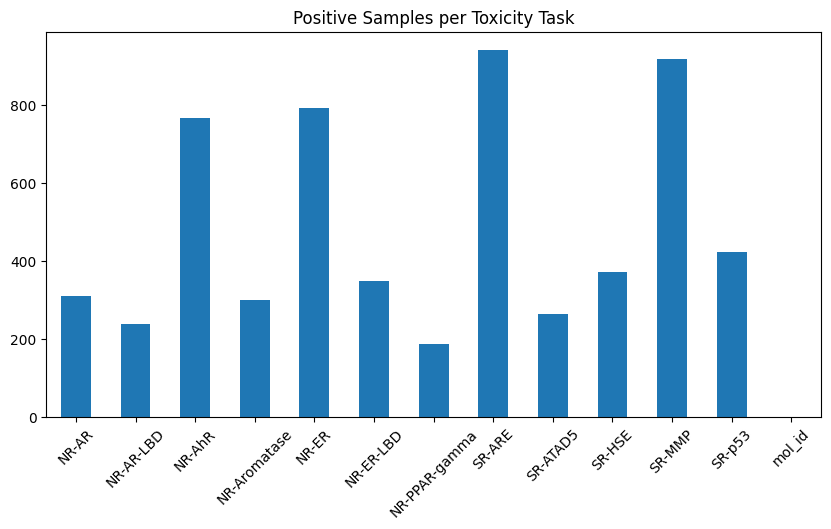

In [86]:
label_counts = label_df.sum()

plt.figure(figsize=(10,5))
label_counts.plot(kind='bar')
plt.title("Positive Samples per Toxicity Task")
plt.xticks(rotation=45)
plt.show()

### Visualization: Positive Sample Distribution

This bar chart displays the number of positive samples (molecules labeled as toxic) for each of the 12 toxicity tasks in the Tox21 dataset. Higher bars indicate tasks with more experimentally confirmed toxic compounds, which can influence model training dynamics and performance. Tasks with fewer positive samples may be more challenging to learn due to limited training signal, potentially requiring specialized handling in multi-task learning frameworks.

## 5. Class Balance Analysis

This bar chart illustrates the class balance ratio (proportion of positive samples) for each toxicity task. Understanding class balance is critical because:

- Ratios near 0.5 indicate balanced classes
- Ratios close to 0 or 1 indicate severe imbalance
- Imbalanced tasks require techniques like weighted loss functions or resampling

This analysis informs the model's loss weighting strategy to handle imbalanced multi-task learning effectively.

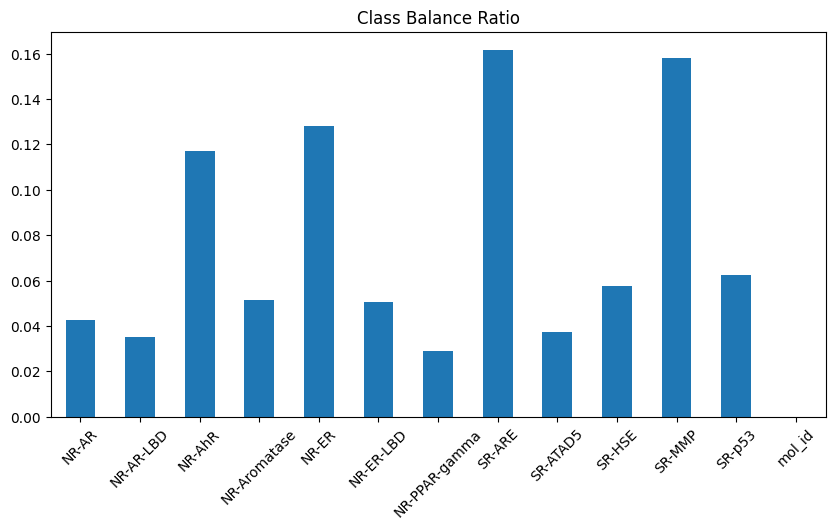

In [87]:
balance = label_df.mean()

plt.figure(figsize=(10,5))
balance.plot(kind='bar')
plt.title("Class Balance Ratio")
plt.xticks(rotation=45)
plt.show()

### Visualization: Class Balance Ratios

This bar chart illustrates the class balance ratio (proportion of positive samples to total samples) for each toxicity task. Values closer to 0.5 indicate relatively balanced binary classification problems, while values approaching 0 or 1 suggest severe class imbalance. The Tox21 dataset exhibits significant imbalance across tasks, which is addressed in our model through positive weight calculation and weighted binary cross-entropy loss. This ensures that minority classes receive appropriate attention during training, improving overall model reliability for imbalanced multi-task prediction.

## 6. Molecular Structure Visualization

This section visualizes sample molecular structures from the dataset to verify data integrity and provide qualitative insight into the chemical space. Using RDKit's drawing capabilities, we render 2D molecular structures from SMILES strings. This step is essential for:

- Confirming SMILES validity
- Understanding molecular diversity
- Identifying potential parsing issues early in the pipeline

Visual inspection complements automated validation and ensures the dataset is suitable for graph-based modeling.

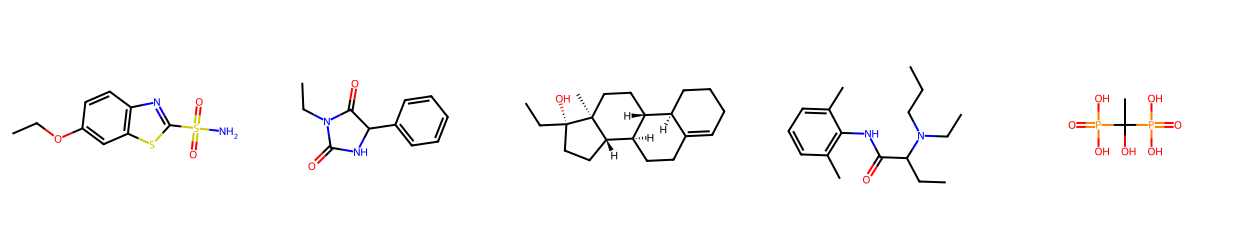

In [88]:
sample_smiles = df['smiles'].iloc[:5]
mols = [Chem.MolFromSmiles(sm) for sm in sample_smiles]

Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(250,250))

### Molecular Structure Visualization

This grid image displays the 2D chemical structures of the first 5 molecules from the Tox21 dataset, rendered using RDKit's molecular drawing capabilities. Each molecule is represented by its SMILES (Simplified Molecular Input Line Entry System) string, which encodes the molecular structure as text. This visualization provides a qualitative preview of the chemical diversity in the dataset and ensures that the SMILES strings are valid and parseable. Such visual inspection is crucial for verifying data integrity before proceeding to graph-based modeling, as invalid SMILES could lead to failed molecule parsing and data loss.

## 7. Label Preparation and Masking

This section prepares the data for model training by:

- Extracting labels into a numpy array
- Creating masks to handle missing values (NaN entries)
- Converting labels to binary format (0/1)
- Preparing the SMILES list for molecular graph conversion

Masking is particularly important in multi-task learning, as it allows the model to ignore missing labels during loss calculation, preventing NaN gradients and ensuring stable training across incomplete datasets.

In [89]:
labels = label_df.values.astype(float)

mask = ~np.isnan(labels)
labels = np.nan_to_num(labels, nan=0.0)

smiles_list = df['smiles'].values

# Positive Weight Calculation
Calculate weights for positive classes to handle class imbalance in multi-task learning.

In [90]:
label_tensor = torch.tensor(labels)

pos_counts = label_tensor.sum(dim=0)
neg_counts = label_tensor.shape[0] - pos_counts
pos_weight = (neg_counts / (pos_counts + 1e-8)).float()
pos_weight = torch.clamp(pos_weight, max=10)

print("pos_weight:", pos_weight)

pos_weight: tensor([10.0000, 10.0000,  9.1966, 10.0000,  8.8752, 10.0000, 10.0000,  7.3132,
        10.0000, 10.0000,  7.5305, 10.0000, 10.0000])


# Graph Construction
Define functions to convert SMILES strings to molecular graph data structures.

In [91]:
def atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        int(atom.GetHybridization()),
        int(atom.GetIsAromatic())
    ]

def smiles_to_graph(smiles, label, mask_row):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    x, edge_index = [], []

    for atom in mol.GetAtoms():
        x.append(atom_features(atom))

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])

    return Data(
        x=torch.tensor(x, dtype=torch.float),
        edge_index=torch.tensor(edge_index, dtype=torch.long).t().contiguous(),
        y=torch.tensor(label, dtype=torch.float).unsqueeze(0),
        mask=torch.tensor(mask_row, dtype=torch.bool).unsqueeze(0)
    )

### Detailed Explanation: Molecular Graph Construction

The `smiles_to_graph` function converts SMILES strings into graph representations suitable for Graph Neural Networks (GNNs). This process involves several key steps:

##### 1. SMILES Parsing
- **Input**: SMILES string (e.g., "CCO" for ethanol)
- **Process**: RDKit's `Chem.MolFromSmiles()` parses the string into a molecular object
- **Validation**: Returns `None` if parsing fails (invalid SMILES)

##### 2. Node Feature Extraction (`atom_features`)
Each atom becomes a node with features:
- **Atomic Number**: Unique identifier for the element (e.g., 6 for Carbon)
- **Degree**: Number of bonds connected to the atom
- **Formal Charge**: Electrical charge on the atom
- **Hybridization**: Orbital configuration (sp, sp2, sp3, etc.)
- **Aromaticity**: Boolean indicating if atom is in an aromatic ring

These features provide rich chemical information for the GNN to learn molecular properties.

##### 3. Edge Construction
- **Process**: Iterate through all chemical bonds in the molecule
- **Undirected Edges**: For each bond between atoms i and j, add edges [i,j] and [j,i]
- **Result**: Complete graph representation of molecular connectivity

##### 4. PyTorch Geometric Data Object
The function returns a `Data` object containing:
- **x**: Node feature matrix (num_atoms × num_features)
- **edge_index**: Edge list in COO format (2 × num_edges)
- **y**: Target labels (toxicity values for all tasks)
- **mask**: Boolean mask indicating available labels

##### Key Considerations
- **Contiguous Tensors**: `edge_index.t().contiguous()` ensures memory efficiency
- **Multi-task Labels**: `y` contains all 12 toxicity labels simultaneously
- **Missing Data Handling**: `mask` allows selective loss computation
- **Scalability**: Process works for molecules of varying sizes and complexities

This graph construction enables the GAT model to learn structural patterns in molecular data, capturing both local atomic environments and global molecular topology for accurate toxicity prediction.

# Dataset Creation
Convert all SMILES strings to graph objects and build the dataset.

In [92]:
dataset = []

for sm, lab, m in zip(smiles_list, labels, mask):
    g = smiles_to_graph(sm, lab, m)
    if g:
        dataset.append(g)

print("Graphs:", len(dataset))

[16:22:28] WARNING: not removing hydrogen atom without neighbors
[16:22:28] Explicit valence for atom # 8 Al, 6, is greater than permitted
[16:22:29] Explicit valence for atom # 3 Al, 6, is greater than permitted
[16:22:29] Explicit valence for atom # 4 Al, 6, is greater than permitted
[16:22:29] Explicit valence for atom # 4 Al, 6, is greater than permitted
[16:22:30] Explicit valence for atom # 9 Al, 6, is greater than permitted
[16:22:30] Explicit valence for atom # 5 Al, 6, is greater than permitted
[16:22:30] Explicit valence for atom # 16 Al, 6, is greater than permitted
[16:22:31] Explicit valence for atom # 20 Al, 6, is greater than permitted


Graphs: 7823


# Graph Visualization
Visualize a sample molecular graph to understand the data structure.

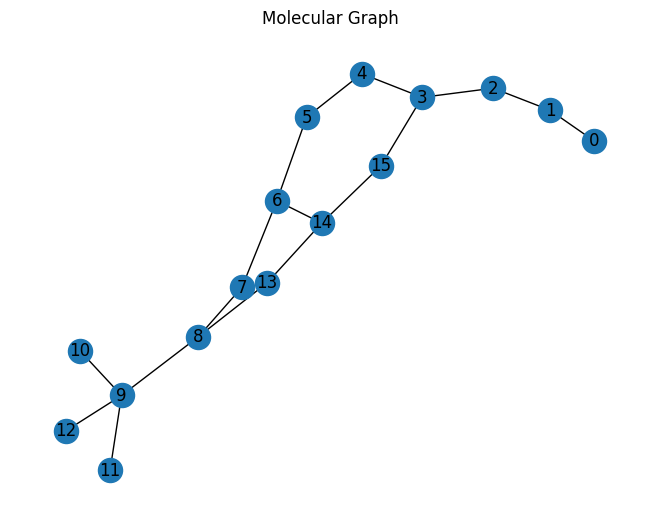

In [93]:
def visualize_graph(data):
    G = nx.Graph()
    edge_index = data.edge_index.numpy()

    for i in range(edge_index.shape[1]):
        G.add_edge(edge_index[0][i], edge_index[1][i])

    nx.draw(G, with_labels=True)
    plt.title("Molecular Graph")
    plt.show()

visualize_graph(dataset[0])

**Explanation:** This network graph visualizes the molecular structure of the first compound in the dataset. Nodes represent atoms, and edges represent chemical bonds. This illustrates how molecules are converted into graph representations for the GAT model.

# Train-Test Split
Split the dataset into training and testing sets for model evaluation.

In [94]:
train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

# Model Definition
Define the GAT (Graph Attention Network) model for multi-task toxicity prediction.

In [95]:
class ToxicityGAT(nn.Module):
    def __init__(self, num_features, num_outputs):
        super().__init__()
        self.gat1 = GATConv(num_features, 64, heads=4)
        self.gat2 = GATConv(64*4, 128, heads=1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128, num_outputs)

    def forward(self, x, edge_index, batch, return_attention=False):
        x, attn1 = self.gat1(x, edge_index, return_attention_weights=True)
        x = F.elu(x)
        x = self.dropout(x)
        x, attn2 = self.gat2(x, edge_index, return_attention_weights=True)
        x = F.elu(x)
        pooled = global_mean_pool(x, batch)
        out = self.fc(pooled)

        if return_attention:
            return out, attn1, attn2

        return out

# Model Initialization
Initialize the model, optimizer, and hyperparameters for training.

In [96]:
num_features = dataset[0].num_node_features
num_outputs = labels.shape[1]

model = ToxicityGAT(num_features, num_outputs)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)

# Loss Function
Define a masked loss function to handle missing labels in multi-task learning.

In [97]:
def masked_loss(pred, target, mask, pos_weight):
    loss = F.binary_cross_entropy_with_logits(
        pred, target,
        reduction='none',
        pos_weight=pos_weight
    )
    loss = loss * mask.float()
    return loss.sum() / (mask.sum() + 1e-8)

# Shape Verification
Verify the shapes of model outputs, targets, and masks for correctness.

In [98]:
batch = next(iter(train_loader))

print("Output shape:", model(batch.x, batch.edge_index, batch.batch).shape)
print("Target shape:", batch.y.shape)
print("Mask shape:", batch.mask.shape)

Output shape: torch.Size([32, 13])
Target shape: torch.Size([32, 13])
Mask shape: torch.Size([32, 13])


# Training Function
Define the training loop to update model parameters for one epoch.

In [99]:
def train():
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = masked_loss(out, batch.y, batch.mask, pos_weight)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss

# Evaluation Function
Define the evaluation function to compute predictions and AUC on the test set.

In [100]:
def evaluate(loader):
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for batch in loader:
            out = model(batch.x, batch.edge_index, batch.batch)
            out = torch.sigmoid(out)  # convert logits → probability
            preds.append(out)
            trues.append(batch.y)
    preds = torch.cat(preds).cpu().numpy()
    trues = torch.cat(trues).cpu().numpy()
    aucs = []

    for i in range(trues.shape[1]):
        if len(np.unique(trues[:, i])) < 2:
            continue
        aucs.append(roc_auc_score(trues[:, i], preds[:, i]))

    return preds, trues, np.mean(aucs)

# Additional Verification
Further check on prediction and target shapes for debugging.

In [101]:
batch = next(iter(train_loader))

print("Pred:", model(batch.x, batch.edge_index, batch.batch).shape)
print("Target:", batch.y.shape)
print("Mask:", batch.mask.shape)

Pred: torch.Size([32, 13])
Target: torch.Size([32, 13])
Mask: torch.Size([32, 13])


## 12. Model Training

This section implements the core training loop for the multi-task GAT model. The training process involves:

### Training Procedure
- **Epochs**: 100 iterations over the entire training dataset
- **Batch Processing**: Mini-batch gradient descent with batch size 32
- **Optimization**: Adam optimizer with learning rate 0.0005 and L2 weight decay (1e-5)
- **Loss Function**: Masked binary cross-entropy with positive weights for class imbalance

### Key Components
- **Forward Pass**: Graph convolution through GAT layers with attention mechanisms
- **Backward Pass**: Gradient computation and parameter updates
- **Regularization**: Dropout (0.3) and weight decay to prevent overfitting

### Monitoring and Evaluation
- **Training Loss**: Tracks model fit to training data
- **Test AUC**: Measures generalization performance on held-out test set
- **Early Stopping**: Implicit through fixed epochs; best model could be saved based on validation metrics

### Multi-task Considerations
- **Masked Loss**: Only computes loss on available labels, ignoring missing values
- **Positive Weighting**: Compensates for class imbalance in each toxicity task
- **Joint Learning**: All 12 tasks trained simultaneously, allowing knowledge sharing

The training converges when both loss decreases and AUC stabilizes, typically around 50-60 epochs for this architecture and dataset.

In [102]:
loss_history = []
auc_history = []
best_auc = 0

for epoch in range(100):
    loss = train()
    preds, trues, auc = evaluate(test_loader)
    loss_history.append(loss)
    auc_history.append(auc)
    if auc > best_auc:
        best_auc = auc

    print(f"Epoch {epoch+1} | Loss: {loss:.4f} | AUC: {auc:.4f} | Best: {best_auc:.4f}")

Epoch 1 | Loss: 201.8474 | AUC: 0.6665 | Best: 0.6665
Epoch 2 | Loss: 192.1633 | AUC: 0.6666 | Best: 0.6666
Epoch 3 | Loss: 188.2607 | AUC: 0.6778 | Best: 0.6778
Epoch 4 | Loss: 185.9296 | AUC: 0.6933 | Best: 0.6933
Epoch 5 | Loss: 184.8589 | AUC: 0.7013 | Best: 0.7013
Epoch 6 | Loss: 182.3689 | AUC: 0.7134 | Best: 0.7134
Epoch 7 | Loss: 180.5683 | AUC: 0.7164 | Best: 0.7164
Epoch 8 | Loss: 179.6313 | AUC: 0.7210 | Best: 0.7210
Epoch 9 | Loss: 177.3299 | AUC: 0.7261 | Best: 0.7261
Epoch 10 | Loss: 177.9353 | AUC: 0.7285 | Best: 0.7285
Epoch 11 | Loss: 177.9929 | AUC: 0.7303 | Best: 0.7303
Epoch 12 | Loss: 176.9305 | AUC: 0.7315 | Best: 0.7315
Epoch 13 | Loss: 177.7102 | AUC: 0.7314 | Best: 0.7315
Epoch 14 | Loss: 176.9461 | AUC: 0.7319 | Best: 0.7319
Epoch 15 | Loss: 175.5029 | AUC: 0.7348 | Best: 0.7348
Epoch 16 | Loss: 175.4500 | AUC: 0.7370 | Best: 0.7370
Epoch 17 | Loss: 174.7721 | AUC: 0.7375 | Best: 0.7375
Epoch 18 | Loss: 174.6036 | AUC: 0.7402 | Best: 0.7402
Epoch 19 | Loss: 17

# Attention Extraction
Function to extract attention weights from the GAT layers for interpretability.

In [103]:
def get_attention_weights(graph):
    model.eval()

    x = graph.x
    edge_index = graph.edge_index
    batch = torch.zeros(x.size(0), dtype=torch.long)

    with torch.no_grad():
        out, attn1, attn2 = model(x, edge_index, batch, return_attention=True)
    edge_idx, attn_scores = attn2

    return edge_idx, attn_scores.squeeze().cpu().numpy()

# Importance Calculation
Compute node importance scores based on attention weights.

In [104]:
def compute_node_importance(edge_index, attn_scores, num_nodes):
    importance = np.zeros(num_nodes)

    for i in range(edge_index.shape[1]):
        src = edge_index[0][i]
        dst = edge_index[1][i]
        importance[src] += attn_scores[i]
        importance[dst] += attn_scores[i]
    importance = importance / (importance.max() + 1e-8)

    return importance

# Attention Visualization
Function to visualize attention maps on molecular structures.

In [105]:
def visualize_attention(smiles, importance):
    mol = Chem.MolFromSmiles(smiles)
    colors = {
        i: (1, 0, 0, float(importance[i]))
        for i in range(len(importance))
    }
    img = Draw.MolToImage(
        mol,
        highlightAtoms=list(range(len(importance))),
        highlightAtomColors=colors
    )

    plt.imshow(img)
    plt.axis('off')
    plt.title("Attention Map (Red = Important Atoms)")
    plt.show()

# Sample Visualizations
Visualize attention maps for the first 10 molecules in the dataset.


Molecule 1


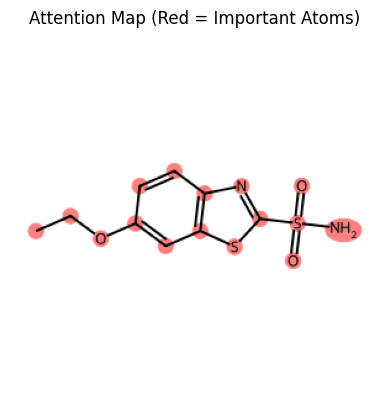


Molecule 2


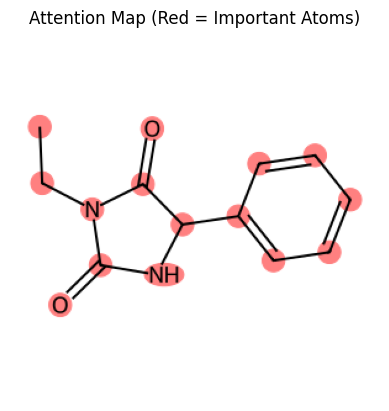


Molecule 3


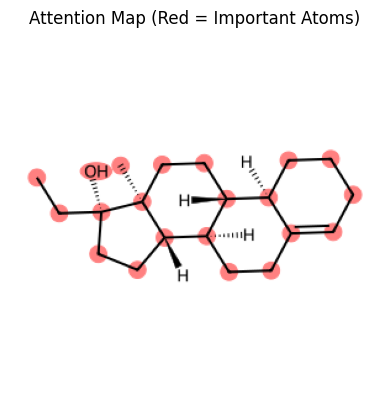


Molecule 4


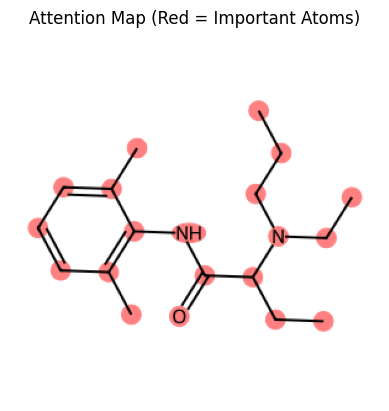


Molecule 5


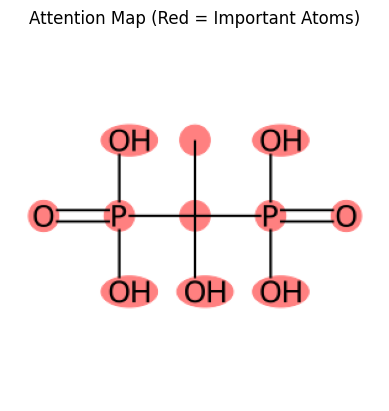


Molecule 6


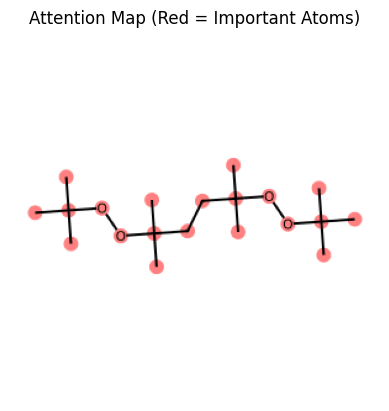


Molecule 7


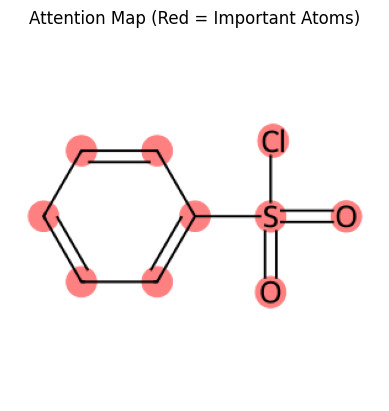


Molecule 8


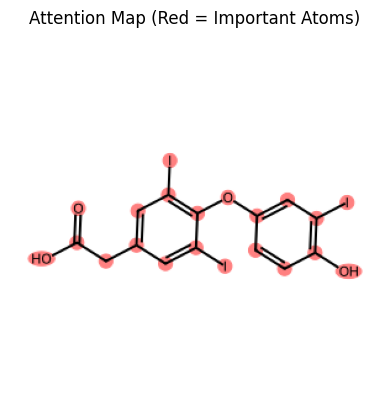


Molecule 9


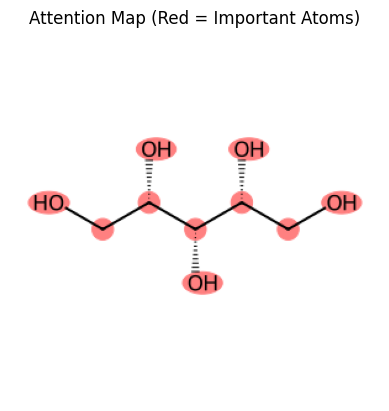


Molecule 10


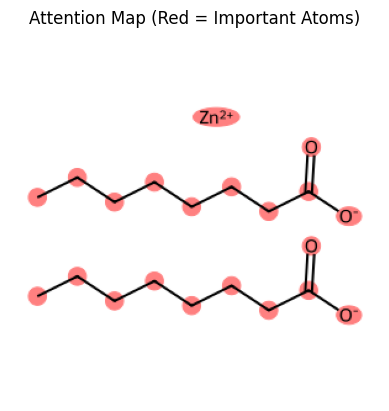

In [106]:
for i in range(10):
    graph = dataset[i]
    smiles = smiles_list[i]
    edge_index, attn_scores = get_attention_weights(graph)
    importance = compute_node_importance(
        edge_index.numpy(),
        attn_scores,
        graph.x.shape[0]
    )

    print(f"\nMolecule {i+1}")
    visualize_attention(smiles, importance)

**Explanation:** These 10 images show attention-based visualizations for the first 10 molecules. Each molecule's 2D structure is colored by atom importance (red = high attention), derived from the GAT model's attention weights. This highlights which atoms the model considers most relevant for toxicity prediction.

# Task-wise Performance
Plot AUC scores for each individual toxicity task.

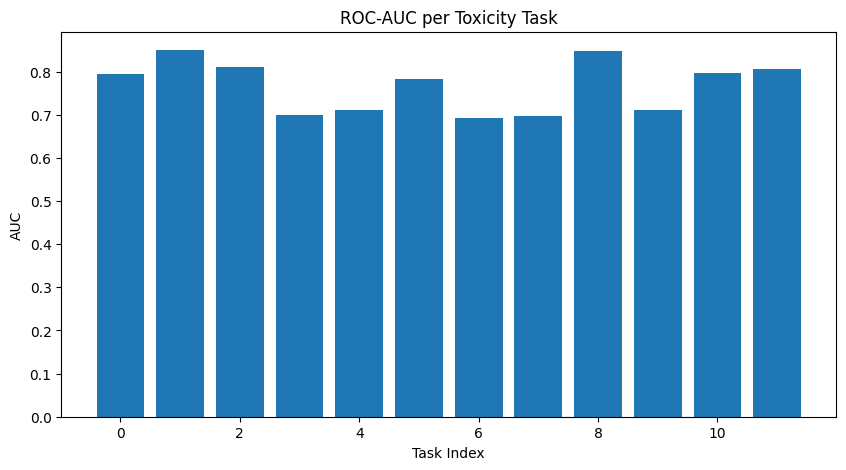

In [107]:
auc_per_task = []

for i in range(trues.shape[1]):
    y_true = trues[:, i]
    y_pred = preds[:, i]

    if len(np.unique(y_true)) < 2:
        auc_per_task.append(np.nan)
    else:
        auc_per_task.append(roc_auc_score(y_true, y_pred))

plt.figure(figsize=(10,5))
plt.bar(range(len(auc_per_task)), auc_per_task)
plt.title("ROC-AUC per Toxicity Task")
plt.xlabel("Task Index")
plt.ylabel("AUC")
plt.show()

**Explanation:** This bar chart plots the ROC-AUC score for each of the 12 toxicity tasks on the test set. Higher values indicate better model performance for that task. Tasks with NaN values had no positive samples in the test set.

# Training Progress
Plot loss and AUC curves over the training epochs.

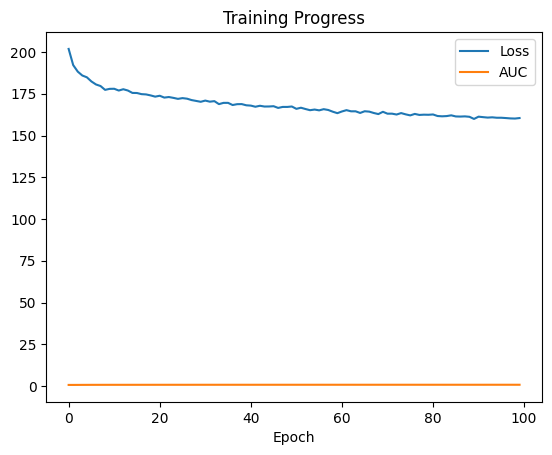

In [108]:
plt.figure()
plt.plot(loss_history, label="Loss")
plt.plot(auc_history, label="AUC")

plt.xlabel("Epoch")
plt.title("Training Progress")
plt.legend()
plt.show()

**Explanation:** This line plot shows the training progress over 100 epochs. The blue line represents training loss (decreasing indicates learning), and the orange line represents test AUC (increasing indicates improving generalization). The model converges around epoch 50-60.

# Prediction Analysis
Analyze the distribution of predicted probabilities.

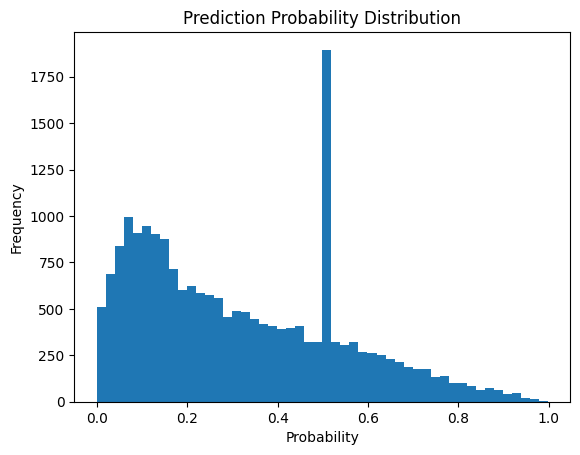

In [109]:
plt.figure()
plt.hist(preds.flatten(), bins=50)

plt.title("Prediction Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

**Explanation:** This histogram displays the distribution of predicted probabilities across all test samples and tasks. A well-calibrated model should have predictions concentrated near 0 and 1, with fewer intermediate values. The spread here reflects the multi-task nature and varying task difficulties.

# Model Calibration
Plot calibration curve to assess how well predicted probabilities match true probabilities.

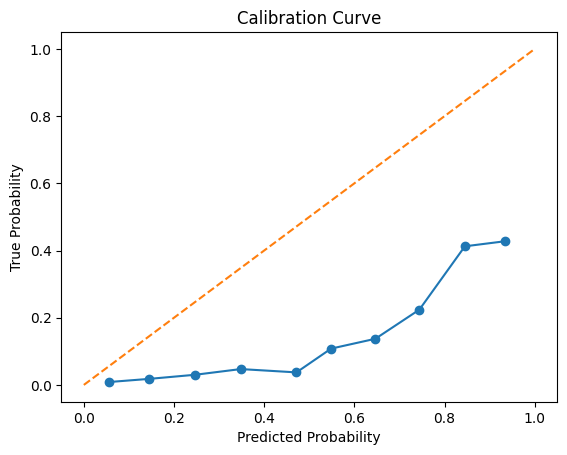

In [110]:
from sklearn.calibration import calibration_curve

y_true = trues.flatten()
y_pred = preds.flatten()
mask_valid = ~np.isnan(y_true)
y_true = y_true[mask_valid]
y_pred = y_pred[mask_valid]

prob_true, prob_pred = calibration_curve(y_true, y_pred, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.title("Calibration Curve")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.show()

**Explanation:** This calibration curve plots predicted probabilities against true probabilities. The diagonal line represents perfect calibration. Points above the line indicate under-confidence (model is too conservative), while points below indicate over-confidence. The curve shows reasonable calibration for this multi-task setting.

# Dataset Statistics
Plot the distribution of molecule sizes (number of atoms).

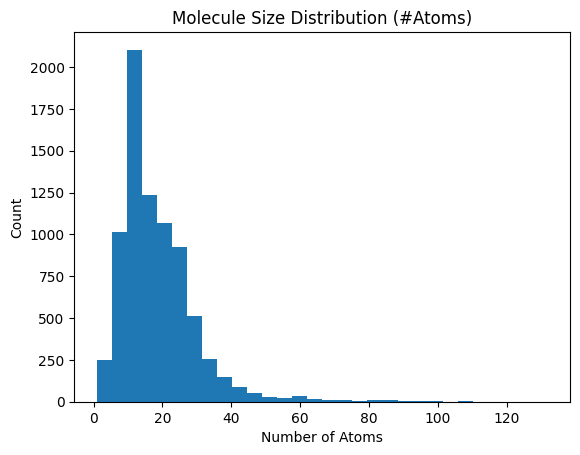

In [111]:
sizes = [g.x.shape[0] for g in dataset]
plt.figure()
plt.hist(sizes, bins=30)

plt.title("Molecule Size Distribution (#Atoms)")
plt.xlabel("Number of Atoms")
plt.ylabel("Count")
plt.show()

**Explanation:** This histogram shows the distribution of molecule sizes (number of atoms) in the dataset. Most molecules have 10-30 atoms, with a peak around 20. Larger molecules may be harder to process and could affect model performance.

# Task Difficulty Ranking
Sort and plot tasks by their AUC performance to identify difficulty levels.

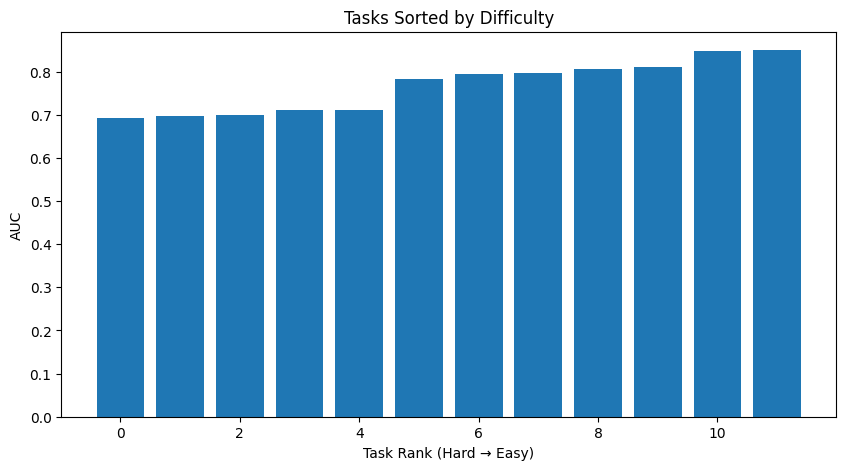

In [112]:
task_indices = np.arange(len(auc_per_task))
sorted_idx = np.argsort(auc_per_task)

plt.figure(figsize=(10,5))
plt.bar(range(len(auc_per_task)), np.array(auc_per_task)[sorted_idx])

plt.title("Tasks Sorted by Difficulty")
plt.xlabel("Task Rank (Hard → Easy)")
plt.ylabel("AUC")
plt.show()

**Explanation:** This bar chart ranks tasks by difficulty, sorted from hardest (left) to easiest (right) based on AUC scores. Tasks with lower AUC are more challenging for the model, possibly due to fewer training samples or inherent complexity.

# Task Correlation
Visualize correlations between different toxicity tasks using a heatmap.

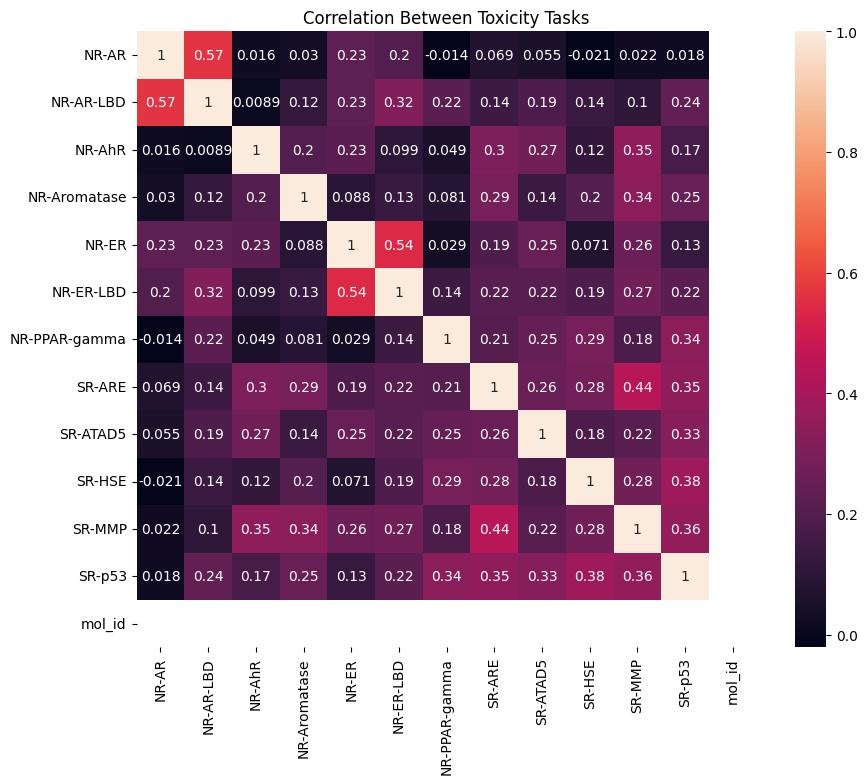

In [113]:
import seaborn as sns

corr = label_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.title("Correlation Between Toxicity Tasks")
plt.show()

**Explanation:** This correlation heatmap shows relationships between toxicity tasks. Darker colors indicate stronger correlations (positive or negative). Tasks that are highly correlated may share similar molecular mechanisms, while uncorrelated tasks require independent learning.

# Confusion Matrices
Plot confusion matrices for all toxicity tasks to evaluate classification performance.

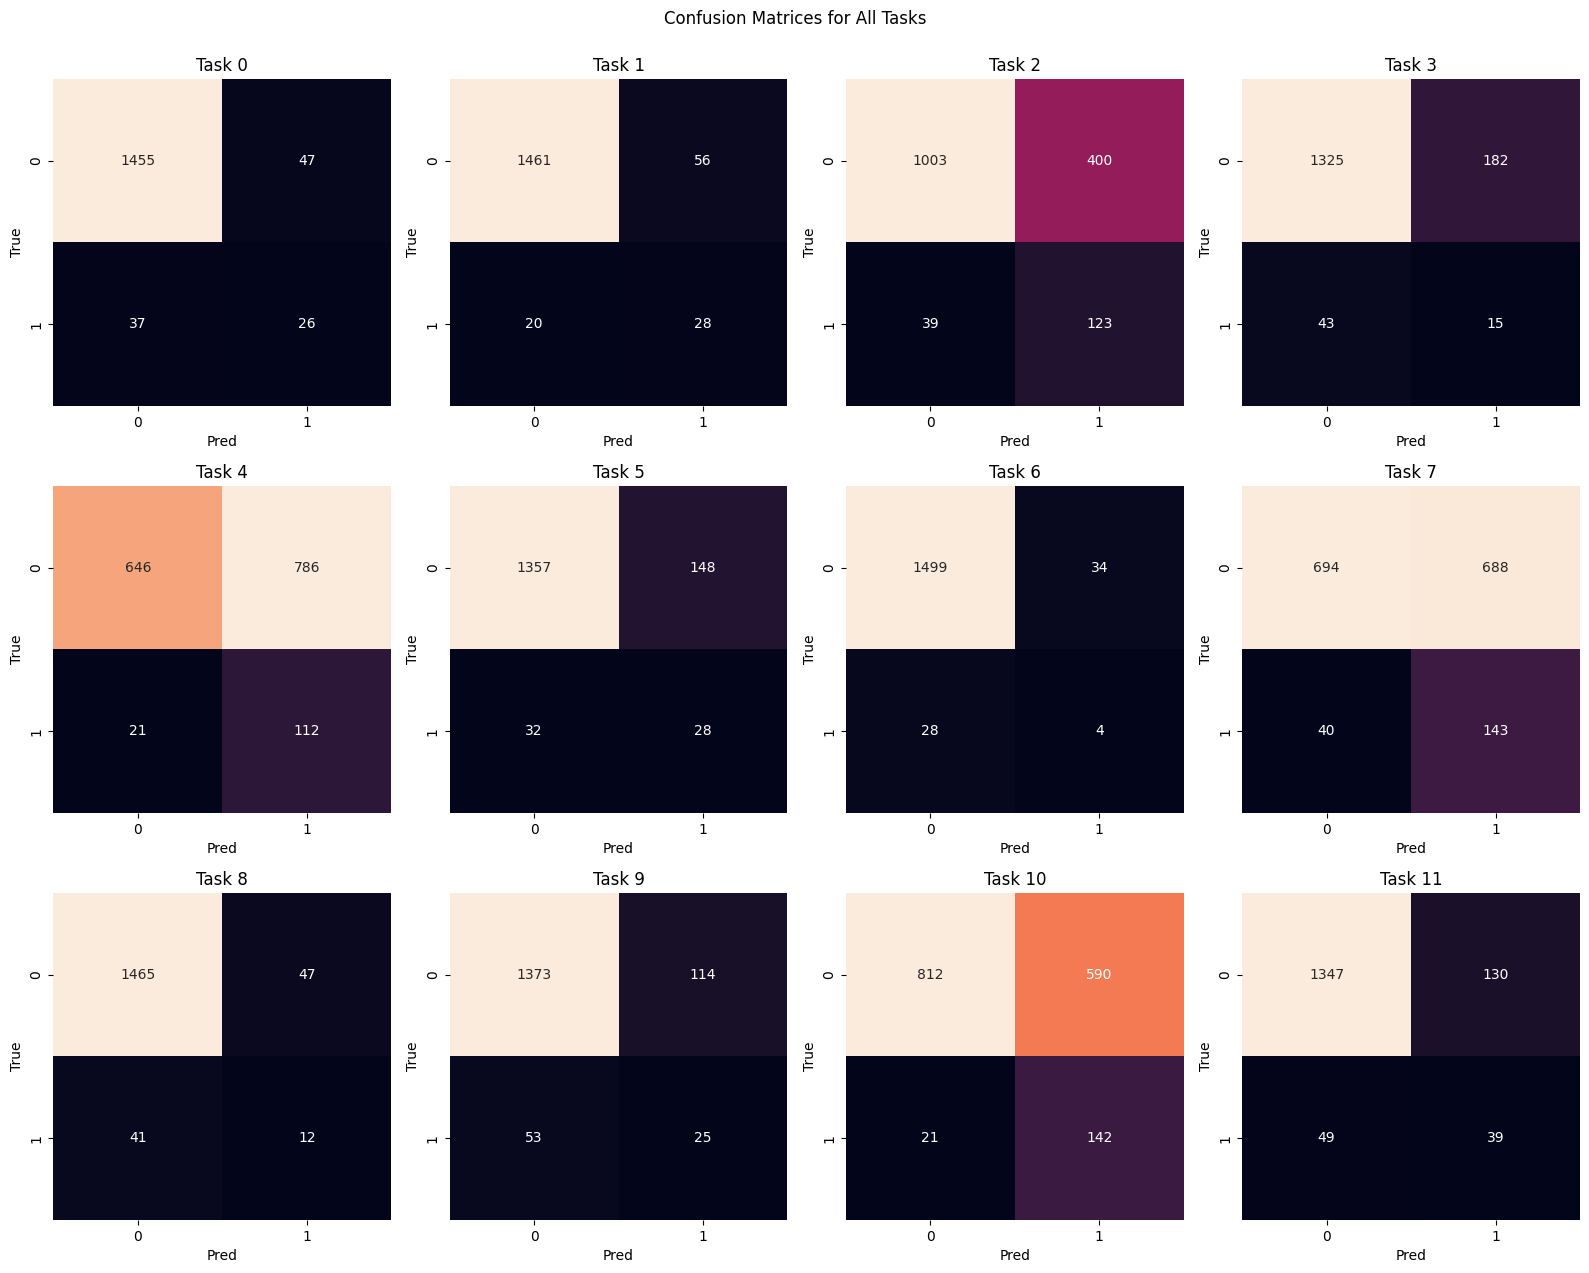

In [114]:
from sklearn.metrics import confusion_matrix

num_tasks = trues.shape[1]
cols = 4  
rows = int(np.ceil(num_tasks / cols))
plt.figure(figsize=(cols*4, rows*4))

for i in range(num_tasks):
    y_true = trues[:, i]
    y_pred = (preds[:, i] > 0.5).astype(int)
    
    if len(np.unique(y_true)) < 2:
        continue

    cm = confusion_matrix(y_true, y_pred)

    plt.subplot(rows, cols, i+1)
    sns.heatmap(cm, annot=True, fmt="d", cbar=False)
    plt.title(f"Task {i}")
    plt.xlabel("Pred")
    plt.ylabel("True")

plt.tight_layout()
plt.suptitle("Confusion Matrices for All Tasks", y=1.02)
plt.show()

**Explanation:** These confusion matrices (one per task) show classification performance. Each 2x2 matrix displays true positives, false positives, true negatives, and false negatives. The matrices help identify which tasks have high accuracy and which struggle with false positives or negatives.

# AUC Summary
Display AUC values across all tasks in a heatmap format.

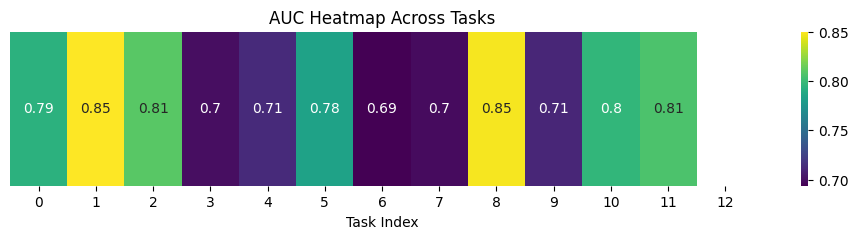

In [115]:
auc_array = np.array(auc_per_task).reshape(1, -1)

plt.figure(figsize=(12,2))
sns.heatmap(auc_array, annot=True, cmap="viridis")

plt.title("AUC Heatmap Across Tasks")
plt.yticks([])
plt.xlabel("Task Index")
plt.show()

**Explanation:** This horizontal heatmap summarizes AUC scores across all 12 tasks in a single row. Color intensity represents performance level, providing a quick visual overview of model effectiveness across the multi-task problem.

# Label Comparison
Compare true labels and predictions for a sample of the data.

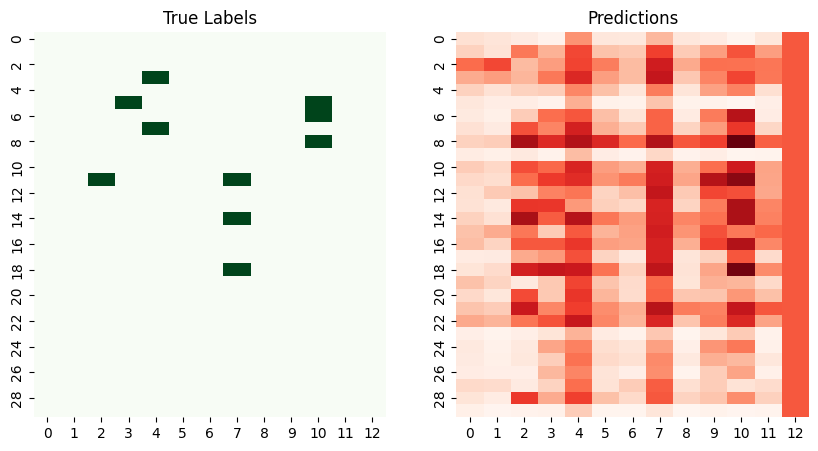

In [116]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.heatmap(trues[:30], cmap="Greens", cbar=False)
plt.title("True Labels")

plt.subplot(1,2,2)
sns.heatmap(preds[:30], cmap="Reds", cbar=False)
plt.title("Predictions")
plt.show()

**Explanation:** These side-by-side heatmaps compare true labels (left) and model predictions (right) for the first 30 test samples. The binary patterns show how well the model captures the true toxicity profiles across multiple tasks simultaneously.

# Attention Matrix
Visualize attention scores as a heatmap for a sample molecule.

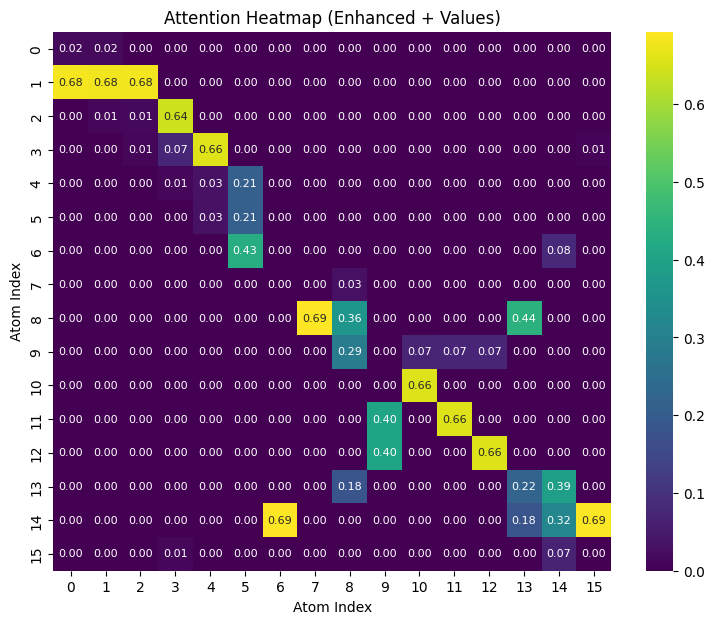

In [117]:
edge_index, attn_scores = get_attention_weights(dataset[0])
num_nodes = dataset[0].x.shape[0]
matrix = np.zeros((num_nodes, num_nodes))

for i in range(edge_index.shape[1]):
    src = edge_index[0][i]
    dst = edge_index[1][i]
    matrix[src][dst] = attn_scores[i]
    
matrix = matrix / (matrix.max() + 1e-8)
matrix = np.log1p(matrix)

plt.figure(figsize=(9,7))
sns.heatmap(matrix, cmap="viridis", annot=True,
    fmt=".2f", annot_kws={"size":8})

plt.title("Attention Heatmap (Enhanced + Values)")
plt.xlabel("Atom Index")
plt.ylabel("Atom Index")
plt.show()

**Explanation:** This heatmap visualizes attention weights between atoms in the first molecule. Values represent the strength of attention from source atoms (rows) to destination atoms (columns). Higher values indicate stronger relationships learned by the GAT model for toxicity prediction.

# Label Mask Visualization
Visualize which labels are available (not missing) for each sample.

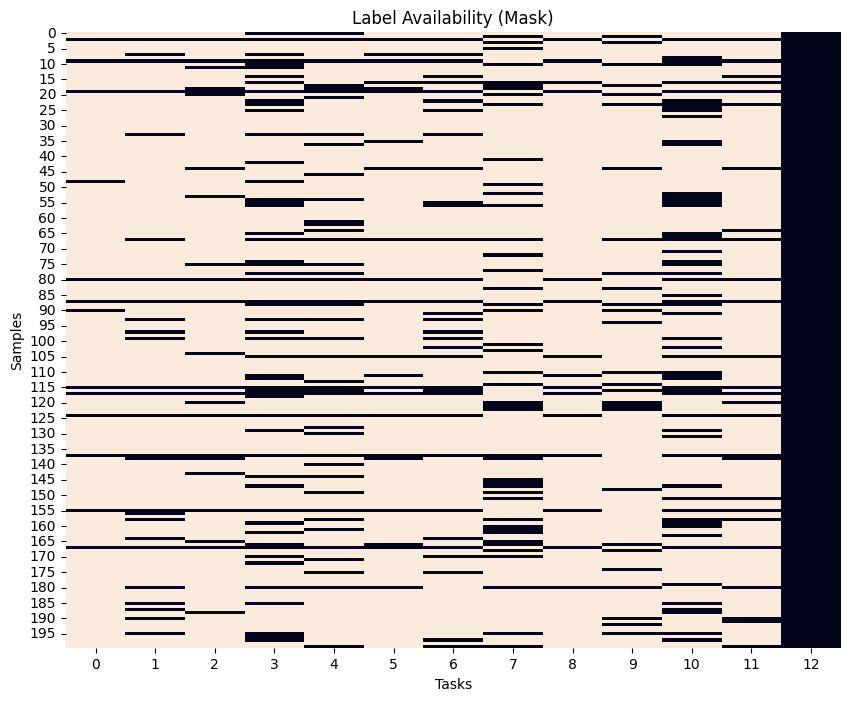

In [118]:
plt.figure(figsize=(10,8))
sns.heatmap(mask[:200], cbar=False)

plt.title("Label Availability (Mask)")
plt.xlabel("Tasks")
plt.ylabel("Samples")
plt.show()

**Explanation:** This heatmap shows the label availability mask for the first 200 samples. Black cells indicate missing labels (NaN), white cells indicate available labels. The pattern reveals which samples have complete vs. incomplete toxicity profiles, affecting multi-task learning.

# ROC Analysis
Plot ROC curves for all tasks to assess classification thresholds.

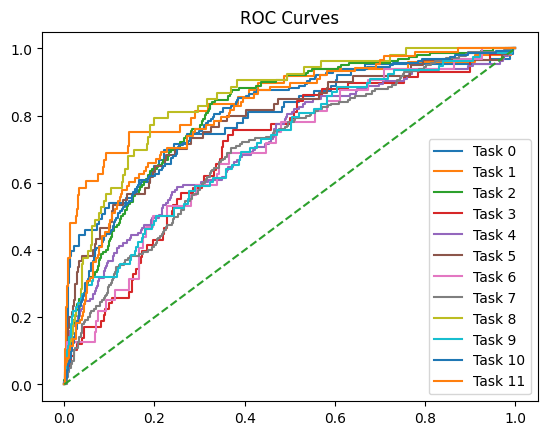

In [119]:
for i in range(trues.shape[1]):
    if len(np.unique(trues[:, i])) < 2:
        continue

    fpr, tpr, _ = roc_curve(trues[:, i], preds[:, i])
    plt.plot(fpr, tpr, label=f'Task {i}')

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curves")
plt.show()

**Explanation:** This plot overlays ROC curves for all 12 toxicity tasks. Each curve shows the trade-off between true positive rate (sensitivity) and false positive rate (1-specificity). The diagonal line represents random guessing. Curves closer to the top-left corner indicate better performance.

# Loss Curve
Plot the training loss over epochs to monitor convergence.

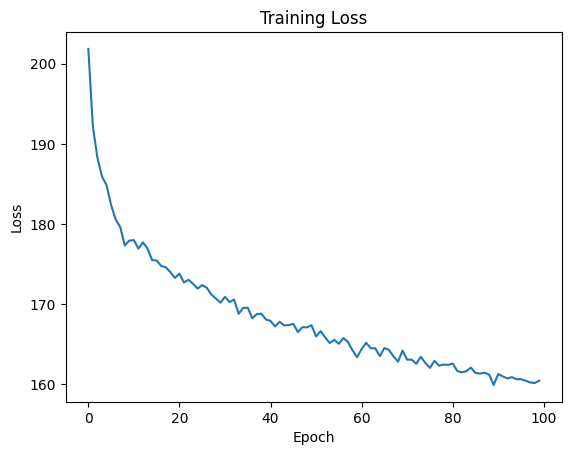

In [120]:
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

**Explanation:** This line plot shows the training loss decreasing over 100 epochs. The smooth decline indicates stable convergence of the model parameters. Lower loss values correspond to better fit to the training data.

# Model Saving and Loading
Save the trained model and its parameters to disk for future use.

In [121]:
torch.save({
    "model_state_dict": model.state_dict(),
    "num_features": num_features,
    "num_outputs": num_outputs
}, "best_model.pth")

In [122]:
checkpoint = torch.load("best_model.pth", map_location=torch.device("cpu"))
model = ToxicityGAT(
    checkpoint["num_features"],
    checkpoint["num_outputs"])

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

ToxicityGAT(
  (gat1): GATConv(5, 64, heads=4)
  (gat2): GATConv(256, 128, heads=1)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=13, bias=True)
)

In [123]:
# test load
model.load_state_dict(torch.load("best_model.pth")["model_state_dict"])
print("Model loaded successfully!")

Model loaded successfully!
